**1. Business/Data Understanding (Sections 1.1-1.3)**

In [ ]:
# Core Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing, Models, Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Deployment Preparation
import pickle # To save the model and scaler

# Setting visualization style
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# CDC Diabetes Health Indicators (BRFSS 2015) — 50/50 balanced split
file_path = "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")

# To display the first few rows (Data Understanding - initial look)
print("\n--- First 5 Rows of the Dataset ---")
print(df.head())

# Printing shape and data types (Data Understanding - structure)
print("\n--- Dataset Info (Shape and Data Types) ---")
df.info()
# Print the shape of the dataset
print ("\n--- Dataset Shape ---")
df.shape

Dataset loaded successfully!

--- First 5 Rows of the Dataset ---
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1              0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2              0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3              0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4              0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0

(70692, 22)


Count of missing values (NaNs)
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Diabetes_binary value counts:
Diabetes_binary
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Descriptive statistics (key numeric fields)
             count       mean        std   min   25%   50%   75%   max
BMI        70692.0  29.856985   7.113954  12.0  25.0  29.0  33.0  98.0
GenHlth    70692.0   2.837082   1.113565   1.0   2.0   3.0   4.0   5.0
MentHlth   70692.0   3.

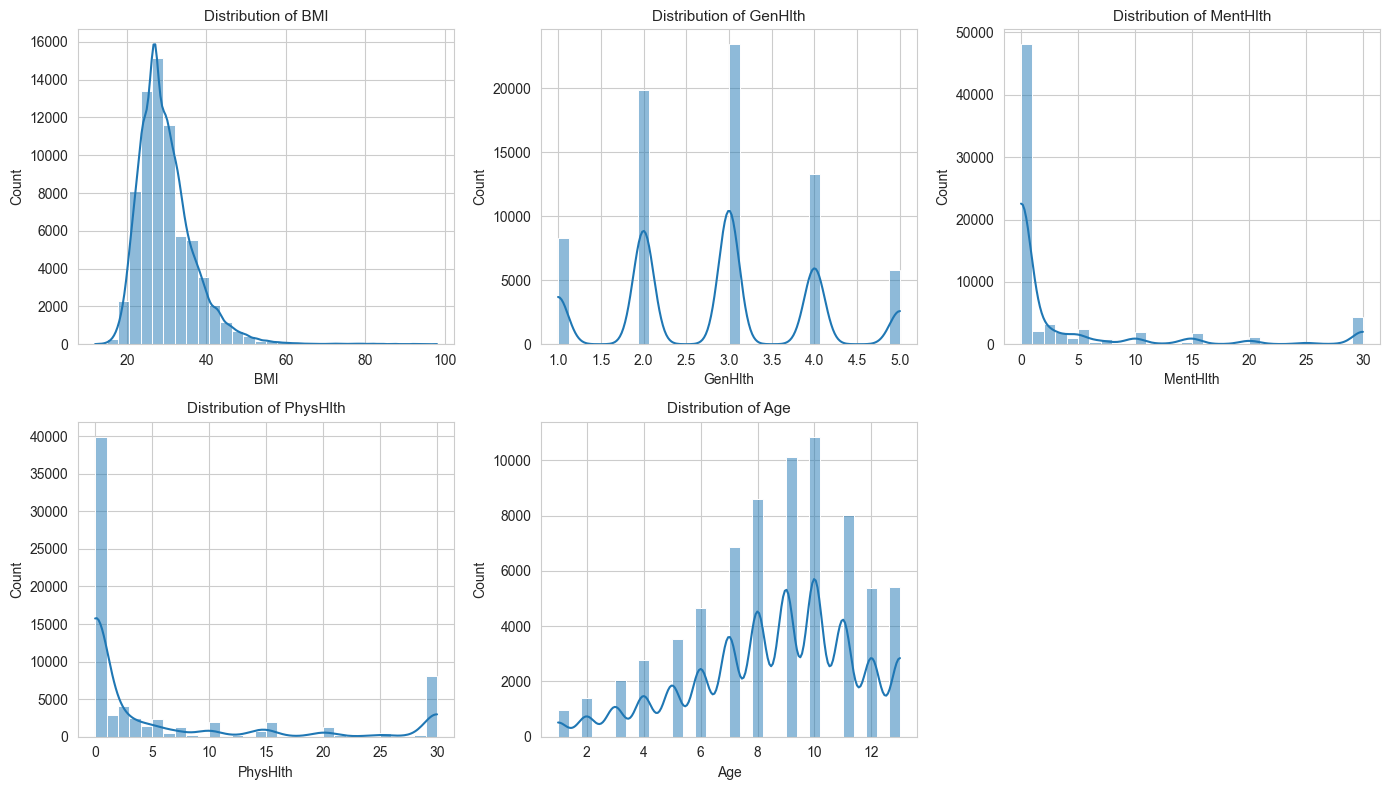

In [ ]:
# 1.3. Initial Data Exploration (CDC / BRFSS Health Indicators)

# 1. Missing values
print("\nCount of missing values (NaNs)")
print(df.isnull().sum())

# 2. Target distribution (50/50 split dataset → expect ~50% each class)
print("\nDiabetes_binary value counts:")
print(df["Diabetes_binary"].value_counts(normalize=True))

# 3. Summary statistics for selected numeric columns
numeric_preview = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income"]
print("\nDescriptive statistics (key numeric fields)")
print(df[numeric_preview].describe().T)

# 4. Quick distributions
plot_cols = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age"]
plt.figure(figsize=(14, 8))
for i, col in enumerate(plot_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}", fontsize=11)
plt.tight_layout()
plt.show()

**2. Data Preparation (Sections 2.1-2.3)**

In [ ]:
# 2.1. BRFSS / CDC encoding — no PIMA-style "invalid zero" handling
# Many fields are intentionally 0/1; zeros are valid. Skip zero→NaN and median imputation.

print("Skipping PIMA-style zero replacement and median imputation for this dataset.")

Skipping PIMA-style zero replacement and median imputation for this dataset.


In [ ]:
# 2.2. Missing values (none expected; address if any appear in your copy)
if df.isnull().sum().sum() > 0:
    print("Warning: missing values detected — impute or drop rows before modeling.")
    print(df.isnull().sum())
else:
    print("No missing values — ready for feature construction.")

No missing values — ready for feature construction.


In [ ]:
# 2.3. Eight-feature subset (BRFSS; compact model)

features_to_keep = [
    "HighBP", "BMI", "Age", "GenHlth", "PhysHlth", "MentHlth", "Sex", "HighChol"
]

X = df[features_to_keep]
y = df["Diabetes_binary"]

In [ ]:
# Standardize all 8 features (including binaries — simple unified pipeline)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Features scaled: shape {X_scaled.shape}")

Features scaled: shape (70692, 8)


In [ ]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (56553, 8)
X_test shape: (14139, 8)
y_train shape: (56553,)
y_test shape: (14139,)


**3. Modeling (Sections 3.2-3.3)**

In [ ]:
#  3.1. Define Evaluation Function

def evaluate_model(model, X_test, y_test, model_name):
    """Calculates and prints key classification metrics."""

    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probability for the positive class (1)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    conf_mat = confusion_matrix(y_test, y_pred)

    print(f"\n--- {model_name} Results ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(conf_mat)

    # Store results for comparison
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# List to store results for final comparison
results = []

In [ ]:
# v2 pipeline: Random Forest Classifier
pass



#####################################################
Starting Training: Random Forest Classifier
#####################################################

--- Random Forest Results ---
Accuracy:  0.7414
Precision: 0.7202
Recall:    0.7895
F1-Score:  0.7533
ROC-AUC:   0.8201

Confusion Matrix:
[[4902 2168]
 [1488 5581]]

--- Generalization Check ---
Training Accuracy: 0.7691
Testing Accuracy:  0.7414
Gap (train - test): 0.0276
Model is Generalized

--- Random Forest Feature Importances ---
    Feature  Importance
3   GenHlth    0.276430
0    HighBP    0.208965
1       BMI    0.175500
2       Age    0.139016
7  HighChol    0.103007
4  PhysHlth    0.057429
5  MentHlth    0.027425
6       Sex    0.012229


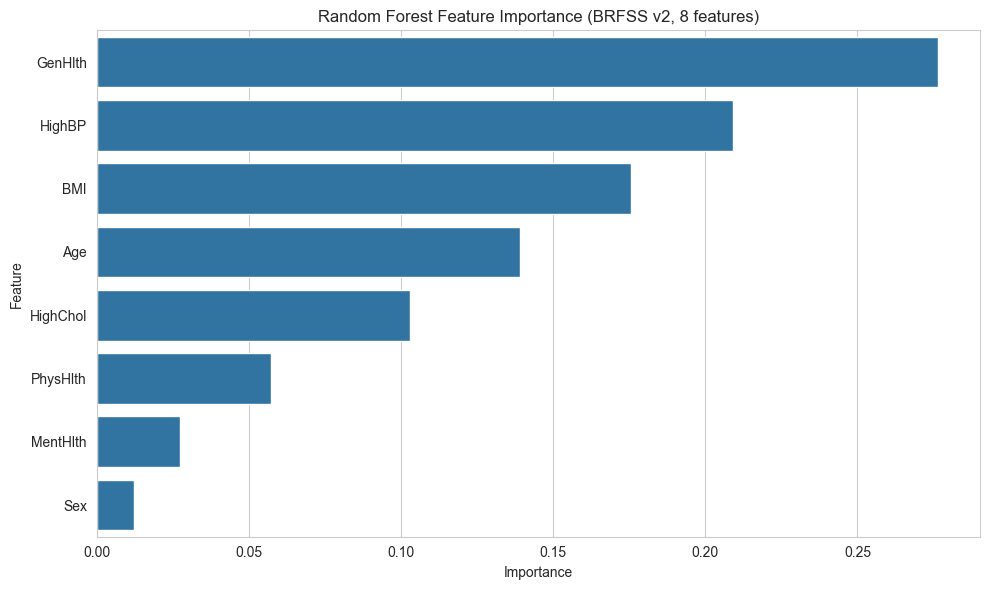

In [ ]:
# 3.3. Random Forest (80/20 train; max_depth limits overfitting)

print("\n\n#####################################################")
print("Starting Training: Random Forest Classifier")
print("#####################################################")

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

rf_metrics = evaluate_model(rf, X_test, y_test, "Random Forest")
results.append(rf_metrics)

train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, rf.predict(X_test))
gap = train_acc - test_acc
print(f"\n--- Generalization Check ---")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap (train - test): {gap:.4f}")
if gap < 0.05:
    print("Model is Generalized")
else:
    print("Train-test gap is 5% or higher; investigate variance / capacity.")

print("\n--- Random Forest Feature Importances ---")
importance_df = pd.DataFrame({
    "Feature": features_to_keep,
    "Importance": rf.feature_importances_,
}).sort_values(by="Importance", ascending=False)
print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Random Forest Feature Importance (BRFSS v2, 8 features)")
plt.tight_layout()
plt.show()


**4. Evaluation (Sections 3.1-3.4)**

In [ ]:
# 3.4. Model summary (Random Forest v2)

print("\n\n#####################################################")
print("Model Summary (Random Forest)")
print("#####################################################")

results_df = pd.DataFrame(results).set_index("Model")
print("\nFinal model performance")
try:
    print(results_df.to_markdown())
except Exception:
    print(results_df)

final_model = rf
final_model_name = "Random Forest"
print(f"\nSelected model: {final_model_name} (BRFSS 50/50, v2 pipeline).")



#####################################################
Model Summary (Random Forest)
#####################################################

Final model performance
               Accuracy  Precision    Recall  F1-Score   ROC-AUC
Model                                                           
Random Forest  0.741424   0.720222  0.789503  0.753273  0.820111

Selected model: Random Forest (BRFSS 50/50, v2 pipeline).


**5. Deployment Preparation (Section 4.1)**

In [ ]:
# 4.1. Save model + StandardScaler

print("\n\n#####################################################")
print("Deployment Preparation: Saving Artifacts (v2)")
print("#####################################################")

model_filename = "final_diabrisk_v2.pkl"
scaler_filename = "scaler_v2.pkl"

try:
    with open(model_filename, "wb") as f:
        pickle.dump(final_model, f)
    print(f"Successfully saved the model as: {model_filename}")
except Exception as e:
    print(f"Error saving the model: {e}")

try:
    with open(scaler_filename, "wb") as f:
        pickle.dump(scaler, f)
    print(f"Successfully saved the scaler as: {scaler_filename}")
except Exception as e:
    print(f"Error saving the scaler: {e}")

print("\nDiabRisk notebook (v2) completed.")




#####################################################
Deployment Preparation: Saving Artifacts (v2)
#####################################################
Successfully saved the model as: final_diabrisk_v2.pkl
Successfully saved the scaler as: scaler_v2.pkl

DiabRisk notebook (v2) completed.
